# XGBoost (2/2) — Bank Customer Churn: a Realistic Project

**Idea:** a bank wants to know *which customers are about to leave* so it can call them first. This is the kind of tabular problem where XGBoost is the industry favourite. We do it properly: validation set, early stopping, class imbalance, tuning, and **one** final test.

**In this notebook**
1. Load the data and spot the class imbalance
2. Preprocess: drop ID columns, encode `Gender` and `Geography`
3. Train / validation / test split (60 / 20 / 20)
4. Baseline `XGBClassifier`
5. Early stopping with a validation set + learning curves
6. Handling imbalance: `scale_pos_weight` and the decision threshold
7. Small `RandomizedSearchCV`
8. Feature importance
9. Final evaluation on the test set (once!)

> 📖 Theory: [`theory.md`](theory.md) §4–§7, §10, §12 · ✍️ = core code to learn · 🎨 = visualization only (collapsed)

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import randint, uniform, loguniform
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report,
                             precision_recall_curve, RocCurveDisplay)

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})
SEED = 42

## 1. Load the data

10,000 bank customers. `Exited = 1` means the customer **left the bank** (churned).

> ✍️ **Core code: learn this.** Load and inspect.

In [2]:
df = pd.read_csv('Churn_Modelling.csv')
print(df.shape)
df.head()

(10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
print('Missing values:', df.isna().sum().sum())
print(df['Exited'].value_counts())
print('Churn rate:', round(df['Exited'].mean(), 4))

Missing values: 0
Exited
0    7963
1    2037
Name: count, dtype: int64
Churn rate: 0.2037


No missing values. **2,037 of 10,000 customers (20.4%) churned**, so the classes are imbalanced (about 4 stayers for every leaver).

> ⚠️ **Imbalanced data trap:** a "model" that always says *"stays"* is already about 80% accurate, and completely useless.
> So in this notebook we judge models by **recall** (how many leavers we catch), **precision** (how many of our alarms are real), **F1** (balance of the two) and **ROC-AUC** (how well the model *ranks* leavers above stayers, independent of threshold).

## 2. Preprocessing

| Column(s) | What to do | Why |
|---|---|---|
| `RowNumber`, `CustomerId`, `Surname` | **drop** | identifiers: no real information (a surname does not make you leave a bank) |
| `Gender` | `Male → 1`, `Female → 0` | XGBoost needs numbers |
| `Geography` (France / Germany / Spain) | **one-hot** encode | no natural order between countries |
| numeric columns | keep as they are | trees do **not** need scaling |

> ✍️ **Core code: learn this.** Drop IDs, encode `Gender`, one-hot encode `Geography`.

In [4]:
data = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])
data['Gender'] = data['Gender'].map({'Female': 0, 'Male': 1})
data = pd.get_dummies(data, columns=['Geography'], dtype=int)

X = data.drop(columns='Exited')
y = data['Exited']
print(X.shape)
X.head()

(10000, 12)


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,1,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1


> 💡 For tree models it is fine to keep all three country columns (no need for `drop_first`). XGBoost also has native categorical support (`enable_categorical=True`), but one-hot encoding is simpler and works everywhere.

## 3. Train / validation / test split

We need **three** sets:

| Set | Size | Used for |
|---|---|---|
| **train** | 60% | fitting the trees |
| **validation** | 20% | early stopping, choosing the threshold, comparing models |
| **test** | 20% | the final, honest score: touched **once**, at the very end |

If we used the test set for early stopping or choosing a threshold, the test score would be optimistic, because the test data would have influenced the model.
`stratify=y` keeps the ~20% churn rate in every set.

> ✍️ **Core code: learn this.** Split twice: first carve out the test set, then split the rest into train and validation.

In [5]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=SEED)  # 0.25 of 80% = 20%

for name, yy in [('train', y_train), ('validation', y_val), ('test', y_test)]:
    print(f'{name:<11} {len(yy):>5} rows   churn rate {yy.mean():.3f}')

train        6000 rows   churn rate 0.204
validation   2000 rows   churn rate 0.203
test         2000 rows   churn rate 0.203


## 4. Baseline XGBoost

A small helper evaluates any model on a given set. It turns predicted **probabilities** into classes using a threshold (0.5 by default).

> ✍️ **Core code: learn this.** The evaluation helper: probabilities → threshold → metrics.

In [6]:
def evaluate(model, X, y, threshold=0.5):
    proba = model.predict_proba(X)[:, 1]          # probability of churn
    pred = (proba >= threshold).astype(int)
    return {'accuracy':  accuracy_score(y, pred),
            'precision': precision_score(y, pred),
            'recall':    recall_score(y, pred),
            'F1':        f1_score(y, pred),
            'ROC-AUC':   roc_auc_score(y, proba)}

results = {}   # validation results of every model we try

> ✍️ **Core code: learn this.** Fit a default `XGBClassifier` and score it on the validation set.

In [7]:
baseline = XGBClassifier(random_state=SEED, n_jobs=4)
baseline.fit(X_train, y_train)

results['1. baseline (default)'] = evaluate(baseline, X_val, y_val)
print('Majority-class accuracy ("always stays"):', round(1 - y_val.mean(), 4))
pd.DataFrame(results).T.round(3)

Majority-class accuracy ("always stays"): 0.7965


,accuracy,precision,recall,F1,ROC-AUC
1. baseline (default),0.856,0.704,0.504,0.587,0.843


The default model reaches **0.856 accuracy**, better than the 0.797 of "always stays". But look at **recall = 0.504**: it catches only about **half** of the customers who actually leave. ROC-AUC is 0.843.
Default XGBoost uses `learning_rate=0.3`, `max_depth=6` and 100 trees, which is quite aggressive. Let's control the number of trees properly.

## 5. Early stopping with a validation set

How many trees should we build? Too few → underfit. Too many → the model starts memorising the training data.
**Early stopping** answers this automatically (theory §4):

1. set `n_estimators` high (an upper limit, e.g. 2000) and a smaller `learning_rate`;
2. pass the **validation set** as `eval_set`;
3. after every tree XGBoost measures the validation loss; if it has not improved for `early_stopping_rounds` trees, it **stops** and remembers the best iteration.

First, let's *see* why we need it: a model with many trees and a high learning rate, **without** early stopping.

In [8]:
overfit = XGBClassifier(n_estimators=500, learning_rate=0.3, max_depth=6,
                        eval_metric='logloss', random_state=SEED, n_jobs=4)
overfit.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], verbose=False)
hist_over = overfit.evals_result()      # loss after every tree, for each eval set
val_loss = hist_over['validation_1']['logloss']
best_round = int(np.argmin(val_loss))          # iterations are counted from 0
print('Best iteration:', best_round, f'({best_round + 1} trees)   best validation log-loss:', round(min(val_loss), 4))
print('Validation log-loss after all 500 trees:', round(val_loss[-1], 4))

Best iteration: 12 (13 trees)   best validation log-loss: 0.3442
Validation log-loss after all 500 trees: 0.5244


Now the proper version with early stopping. `eval_metric` and `early_stopping_rounds` go in the **constructor** (XGBoost ≥ 2.0); the eval set goes in `fit`.
The **last** set in `eval_set` is the one used for early stopping, so we put the validation set last.

> ✍️ **Core code: learn this.** Early stopping: big `n_estimators`, small `learning_rate`, `early_stopping_rounds`, and `eval_set` = validation data.

In [9]:
es_model = XGBClassifier(
    n_estimators=2000,            # upper limit; early stopping will cut it
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,                # each tree sees 80% of the rows
    colsample_bytree=0.8,         # ... and 80% of the columns
    eval_metric='logloss',
    early_stopping_rounds=50,     # stop if validation loss has not improved for 50 trees
    random_state=SEED, n_jobs=4)

es_model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], verbose=False)
print('Best iteration:', es_model.best_iteration, f'({es_model.best_iteration + 1} trees)   best validation log-loss:', round(es_model.best_score, 4))
print('Trees actually built:', es_model.get_booster().num_boosted_rounds())

results['2. early stopping'] = evaluate(es_model, X_val, y_val)
pd.DataFrame(results).T.round(3)

Best iteration: 143 (144 trees)   best validation log-loss: 0.3394
Trees actually built: 194


,accuracy,precision,recall,F1,ROC-AUC
1. baseline (default),0.856,0.704,0.504,0.587,0.843
2. early stopping,0.862,0.779,0.450,0.570,0.862


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

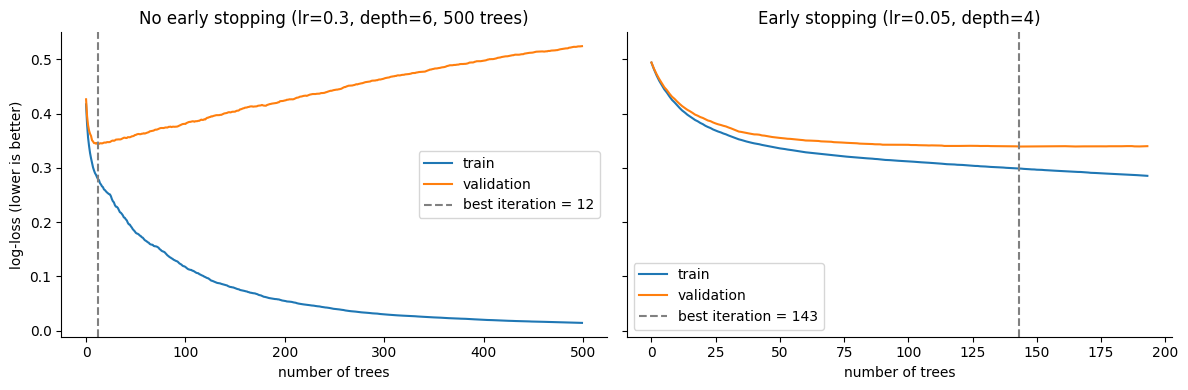

In [10]:
hist_es = es_model.evals_result()
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, hist, title, best in [(axes[0], hist_over, 'No early stopping (lr=0.3, depth=6, 500 trees)', best_round),
                              (axes[1], hist_es, 'Early stopping (lr=0.05, depth=4)', es_model.best_iteration)]:
    ax.plot(hist['validation_0']['logloss'], label='train')
    ax.plot(hist['validation_1']['logloss'], label='validation')
    ax.axvline(best, color='gray', ls='--', label=f'best iteration = {best}')
    ax.set_title(title); ax.set_xlabel('number of trees'); ax.legend()
axes[0].set_ylabel('log-loss (lower is better)')
plt.tight_layout(); plt.show()

**Left (no early stopping):** the validation loss is lowest after only **13 trees** (0.344) and then climbs steadily to **0.524** at 500 trees, while the training loss keeps falling towards 0. This is classic **overfitting**: the model memorises the training data.

**Right (early stopping):** with a smaller learning rate the curves fall slowly. The best validation loss (**0.339**) is reached at iteration **143** (144 trees); XGBoost built 50 more trees, saw no improvement, and stopped at 194 instead of 2000.

On the validation set, ROC-AUC improved from **0.843 → 0.862** compared with the baseline. Precision went up (0.704 → 0.779) but recall went *down* (0.504 → 0.450): at threshold 0.5 the model is still too cautious about predicting churn. That's the next problem.

> 💡 When early stopping was used, `predict` / `predict_proba` automatically use only the trees up to `best_iteration`.

## 6. Handling the imbalance

At threshold 0.5 the model catches only part of the leavers (see recall). Two simple fixes (theory §7):

**a) `scale_pos_weight`** = (number of negatives) / (number of positives). Each churner then counts about 4× in the loss, so the model pays more attention to them.

> ✍️ **Core code: learn this.** Compute `scale_pos_weight` from the training labels and retrain with early stopping.

In [11]:
spw = (y_train == 0).sum() / (y_train == 1).sum()
print('scale_pos_weight =', round(spw, 2))

weighted = XGBClassifier(n_estimators=2000, learning_rate=0.05, max_depth=4, subsample=0.8, colsample_bytree=0.8,
                         scale_pos_weight=spw, eval_metric='logloss', early_stopping_rounds=50,
                         random_state=SEED, n_jobs=4)
weighted.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
print('Best iteration:', weighted.best_iteration)

results['3. scale_pos_weight'] = evaluate(weighted, X_val, y_val)
pd.DataFrame(results).T.round(3)

scale_pos_weight = 3.91


Best iteration: 767


,accuracy,precision,recall,F1,ROC-AUC
1. baseline (default),0.856,0.704,0.504,0.587,0.843
2. early stopping,0.862,0.779,0.450,0.570,0.862
3. scale_pos_weight,0.828,0.564,0.686,0.619,0.850


With `scale_pos_weight = 3.91`, recall jumps from **0.450 to 0.686**: we now catch about two thirds of the leavers. The price: precision falls from 0.779 to 0.564 (more false alarms), and accuracy drops a bit (0.862 → 0.828). F1 improves (0.570 → 0.619). ROC-AUC is slightly lower (0.850 vs 0.862); this model also needed many more trees (best iteration 767).

**b) Move the decision threshold.** Instead of reweighting, keep the early-stopping model and lower the threshold from 0.5. We choose the threshold that gives the best **F1 on the validation set**.

> ✍️ **Core code: learn this.** Find the F1-maximising threshold on the validation set with `precision_recall_curve`.

In [12]:
def best_f1_threshold(model, X, y):
    proba = model.predict_proba(X)[:, 1]
    prec, rec, thr = precision_recall_curve(y, proba)
    f1 = 2 * prec * rec / (prec + rec + 1e-12)
    i = np.argmax(f1[:-1])                 # the last (prec, rec) pair has no threshold
    return thr[i], prec, rec, thr, f1

thr_es, prec, rec, thr, f1 = best_f1_threshold(es_model, X_val, y_val)
print('Best threshold on validation:', round(thr_es, 3))

results[f'4. early stopping, threshold {thr_es:.2f}'] = evaluate(es_model, X_val, y_val, threshold=thr_es)
pd.DataFrame(results).T.round(3)

Best threshold on validation: 0.282


,accuracy,precision,recall,F1,ROC-AUC
1. baseline (default),0.856,0.704,0.504,0.587,0.843
2. early stopping,0.862,0.779,0.450,0.570,0.862
3. scale_pos_weight,0.828,0.564,0.686,0.619,0.850
"4. early stopping, threshold 0.28",0.846,0.607,0.681,0.642,0.862


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

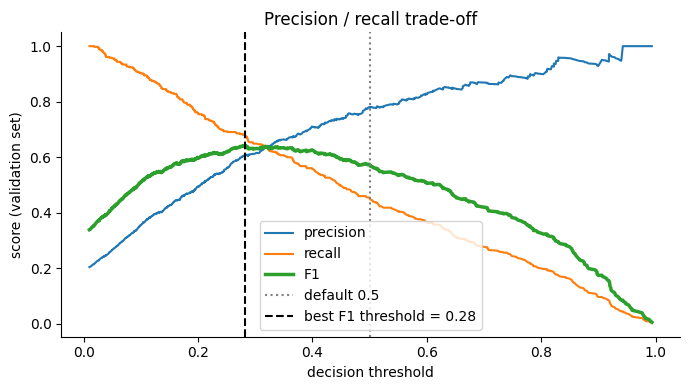

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thr, prec[:-1], label='precision')
ax.plot(thr, rec[:-1], label='recall')
ax.plot(thr, f1[:-1], label='F1', lw=2.5)
ax.axvline(0.5, color='gray', ls=':', label='default 0.5')
ax.axvline(thr_es, color='k', ls='--', label=f'best F1 threshold = {thr_es:.2f}')
ax.set_xlabel('decision threshold'); ax.set_ylabel('score (validation set)')
ax.set_title('Precision / recall trade-off'); ax.legend(); plt.tight_layout(); plt.show()

As the threshold goes down, **recall rises and precision falls**. F1 is highest at **threshold 0.28**.
With that threshold the early-stopping model gets recall **0.681** and precision **0.607**, F1 **0.642**: about the same recall as `scale_pos_weight`, but with better precision. ROC-AUC stays exactly **0.862**, because moving the threshold does not change the predicted probabilities, only how we cut them.

## 7. A small RandomizedSearchCV

Instead of trying every combination (grid search), `RandomizedSearchCV` tries **25 random combinations** from the ranges below, each with 3-fold CV on the **training set** only.
We score by **ROC-AUC** because it does not depend on the threshold (we choose the threshold afterwards on the validation set).

> We do not use early stopping inside the search (it would need its own validation data in every fold), so `n_estimators` is searched like any other parameter.

> ✍️ **Core code: learn this.** Define the search space and run `RandomizedSearchCV`.

In [14]:
param_dist = {
    'n_estimators':     randint(100, 600),
    'learning_rate':    loguniform(0.01, 0.3),
    'max_depth':        randint(2, 7),
    'min_child_weight': randint(1, 10),
    'subsample':        uniform(0.6, 0.4),        # 0.6 – 1.0
    'colsample_bytree': uniform(0.6, 0.4),        # 0.6 – 1.0
    'gamma':            uniform(0, 3),
    'reg_lambda':       loguniform(0.1, 10),
}
search = RandomizedSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=SEED, n_jobs=1),
    param_dist, n_iter=25, scoring='roc_auc',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED),
    random_state=SEED, n_jobs=4)

start = time.time()
search.fit(X_train, y_train)
print(f'Search took {time.time() - start:.0f} s')
print('Best CV ROC-AUC:', round(search.best_score_, 4))
pd.Series(search.best_params_).round(3)

Search took 23 s
Best CV ROC-AUC: 0.8618


colsample_bytree      0.943
gamma                 0.978
learning_rate         0.021
max_depth             3.000
min_child_weight      3.000
n_estimators        246.000
reg_lambda            0.498
subsample             0.638
dtype: float64

> ✍️ **Core code: learn this.** Evaluate the tuned model on validation, with its own F1-best threshold.

In [15]:
tuned = search.best_estimator_            # already refit on the whole training set
thr_tuned = best_f1_threshold(tuned, X_val, y_val)[0]
print('Best threshold on validation:', round(thr_tuned, 3))
results[f'5. tuned, threshold {thr_tuned:.2f}'] = evaluate(tuned, X_val, y_val, threshold=thr_tuned)
val_table = pd.DataFrame(results).T.round(3)
val_table

Best threshold on validation: 0.33


,accuracy,precision,recall,F1,ROC-AUC
1. baseline (default),0.856,0.704,0.504,0.587,0.843
2. early stopping,0.862,0.779,0.450,0.570,0.862
3. scale_pos_weight,0.828,0.564,0.686,0.619,0.850
"4. early stopping, threshold 0.28",0.846,0.607,0.681,0.642,0.862
"5. tuned, threshold 0.33",0.860,0.675,0.602,0.636,0.860


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

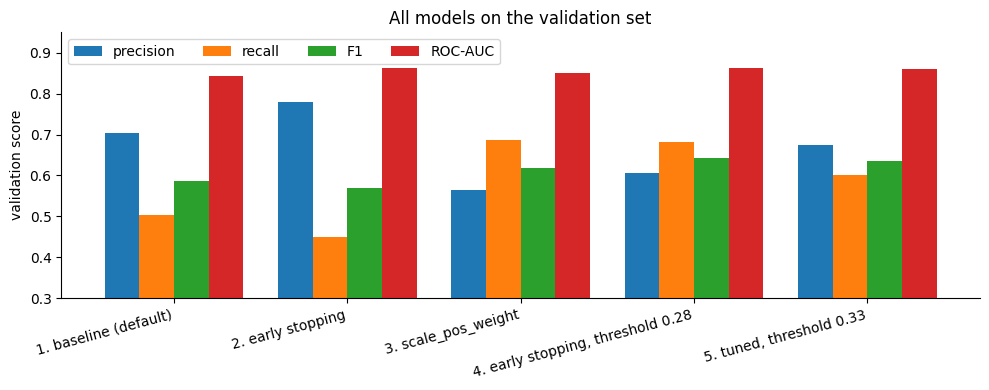

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
val_table[['precision', 'recall', 'F1', 'ROC-AUC']].plot.bar(ax=ax, width=0.8)
ax.set_ylim(0.3, 0.95); ax.set_ylabel('validation score')
ax.set_title('All models on the validation set')
ax.set_xticklabels(val_table.index, rotation=15, ha='right')
ax.legend(loc='upper left', ncol=4); plt.tight_layout(); plt.show()

**Honest result:** the search ran in well under a minute and found a slow, shallow model (`learning_rate ≈ 0.021`, `max_depth=3`, 246 trees), with CV ROC-AUC 0.862. On the validation set it scores ROC-AUC **0.860** and F1 **0.636** (threshold 0.33), i.e. **no better** than our hand-picked early-stopping model (ROC-AUC 0.862, F1 0.642).
This is common: once the learning rate and number of trees are sensible, extra tuning usually adds very little. A bigger search might help slightly, but the differences here are within noise.

## 8. Choose the final model, then feature importance

**Choice rule (decided on validation only):** our goal is to catch churners without too many false alarms, so we pick the model with the highest **validation F1**: model 4, *early stopping + threshold 0.28*.
Which customer features drive its predictions?

In [17]:
final_model, final_thr = es_model, thr_es      # model 4: best validation F1
imp = pd.Series(final_model.feature_importances_, index=X.columns).sort_values(ascending=False)
imp.round(3)

NumOfProducts        0.268
IsActiveMember       0.178
Age                  0.171
Geography_Germany    0.095
Gender               0.057
Balance              0.051
Geography_France     0.034
Geography_Spain      0.034
CreditScore          0.031
EstimatedSalary      0.030
Tenure               0.027
HasCrCard            0.025
dtype: float32

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

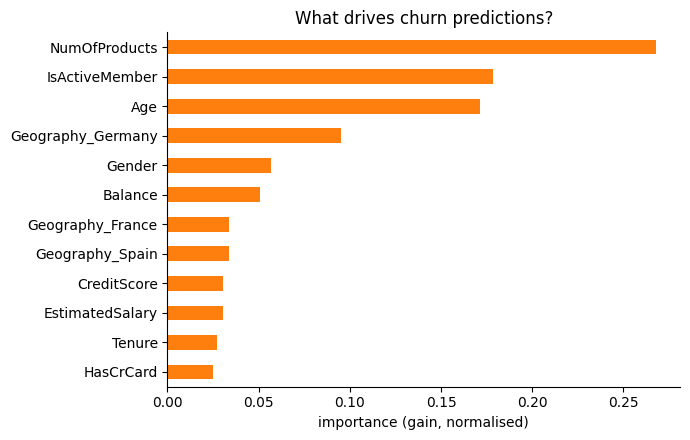

In [18]:
fig, ax = plt.subplots(figsize=(7, 4.5))
imp.sort_values().plot.barh(ax=ax, color='tab:orange')
ax.set_xlabel('importance (gain, normalised)'); ax.set_title('What drives churn predictions?')
plt.tight_layout(); plt.show()

The top drivers are **NumOfProducts** (0.268), **IsActiveMember** (0.178) and **Age** (0.171), followed by **Geography_Germany** (0.095). Customer ID-like information is gone, and things such as `HasCrCard`, `Tenure` and `EstimatedSalary` matter least. This makes business sense: inactive customers, older customers and customers with an unusual number of products are the ones the model flags.

> ⚠️ Gain importance can change between models and favours features used in high-gain splits. For a more robust view, use `sklearn.inspection.permutation_importance` or SHAP values.

## 9. Final evaluation on the test set (once!)

Everything is decided: the model and the threshold were chosen using the validation set only. Now we touch the test set **one time**.

> ✍️ **Core code: learn this.** Evaluate the final model and threshold on the test set.

In [19]:
test_scores = evaluate(final_model, X_test, y_test, threshold=final_thr)
print('Threshold:', round(final_thr, 3))
print(pd.Series(test_scores).round(3))

test_pred = (final_model.predict_proba(X_test)[:, 1] >= final_thr).astype(int)
print(classification_report(y_test, test_pred, target_names=['stays', 'churns']))

Threshold: 0.282
accuracy     0.842
precision    0.599
recall       0.683
F1           0.638
ROC-AUC      0.868
dtype: float64
              precision    recall  f1-score   support

       stays       0.92      0.88      0.90      1593
      churns       0.60      0.68      0.64       407

    accuracy                           0.84      2000
   macro avg       0.76      0.78      0.77      2000
weighted avg       0.85      0.84      0.85      2000



> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

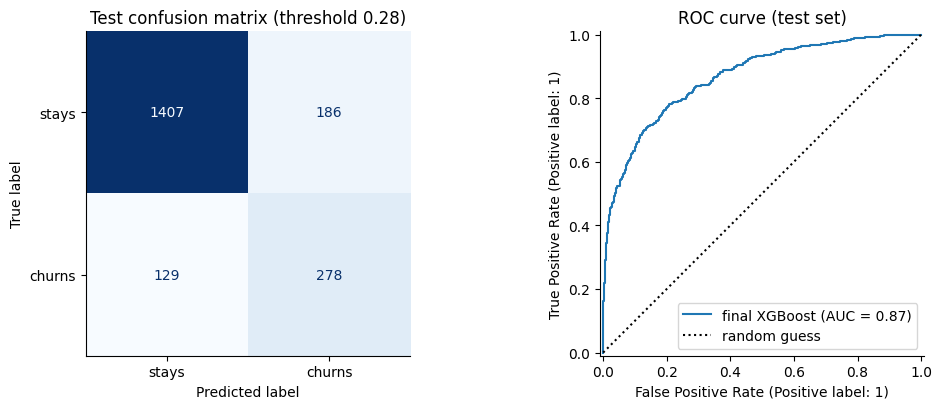

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
ConfusionMatrixDisplay(confusion_matrix(y_test, test_pred), display_labels=['stays', 'churns']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Test confusion matrix (threshold {final_thr:.2f})')
RocCurveDisplay.from_estimator(final_model, X_test, y_test, ax=axes[1], name='final XGBoost')
axes[1].plot([0, 1], [0, 1], 'k:', label='random guess'); axes[1].legend(loc='lower right')
axes[1].set_title('ROC curve (test set)')
plt.tight_layout(); plt.show()

**Final test result (threshold 0.28):** ROC-AUC **0.868**, recall **0.683**, precision **0.599**, F1 **0.638**, accuracy 0.842.
- We catch **278 of the 407** customers who actually left (68%).
- 186 customers were flagged but stayed (false alarms); 129 leavers were missed.
- The test scores are very close to the validation scores (F1 0.642, ROC-AUC 0.862), so our choices did not overfit the validation set.

For the bank this means: call the ~460 flagged customers, and about 6 in 10 of them really were about to leave.

## Key takeaways
- Use **three** sets: train (fit), validation (early stopping, threshold, model choice), test (final score, once).
- **Early stopping** picks the number of trees for you: set `n_estimators` high, pass `eval_set=[(X_val, y_val)]`, set `early_stopping_rounds`.
- With imbalanced data, accuracy is misleading: look at **recall, precision, F1, ROC-AUC**.
- `scale_pos_weight` and **threshold tuning** both trade precision for recall; ROC-AUC barely changes because the *ranking* stays similar.
- Final model on the test set: **ROC-AUC 0.868, recall 0.683, F1 0.638** (vs recall 0.504 for the untuned default on validation). Random search did **not** beat the simple early-stopping model.

## 🧠 Quick check

<details><summary>1. Why must early stopping use the validation set and not the test set?</summary>
Early stopping chooses the number of trees by looking at the eval set. If that is the test set, the test data has influenced the model, so the test score is optimistic and no longer an honest estimate.
</details>

<details><summary>2. Only ~20% of customers churn. Why is 80% accuracy not impressive?</summary>
Predicting "stays" for everyone already gives ~80% accuracy while catching zero churners. Recall, precision, F1 and ROC-AUC tell us much more.
</details>

<details><summary>3. What does <code>scale_pos_weight = 3.9</code> do?</summary>
Each positive (churn) example counts about 3.9 times as much in the loss, which balances the classes. The model then predicts churn more often: recall goes up, precision goes down.
</details>

<details><summary>4. Why did ROC-AUC hardly change when we moved the threshold?</summary>
ROC-AUC measures how well the model ranks churners above non-churners over <em>all</em> thresholds. Moving the threshold does not change the predicted probabilities, so it does not change AUC at all for the same model.
</details>

➡️ **Next:** [`../08-stacking-and-blending/`](../08-stacking-and-blending/): combine different models with a meta-model.